# MarketPulse Analytics — AI-Based Marketing Campaign Analysis
End-to-end ML system for marketing campaign data.

**Models used**
1. K-Means — Customer segmentation (High / Medium / Low value)
2. Logistic Regression — Conversion prediction (Yes/No)
3. Isolation Forest — Anomaly detection (unusual campaigns)

**Bonus**
- Channel recommendation
- Predicted ROI per channel


## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('marketing_campaigns.csv')
print(df.shape)
df.head()

(5000, 17)


,customer_id,campaign_id,channel,region,device,age,income,tenure_months,prev_purchases,session_duration_min,pages_viewed,spend,impressions,clicks,conversions,revenue,converted
0,C00000,CMP_014,Influencer,Central,Mobile,21,21100.0,47,4,15.98,5,1089.10,66604,1535,0,0.00,0
1,C00001,CMP_009,Search,South,Mobile,44,75349.0,76,5,4.38,7,629.89,29018,1693,0,0.00,0
2,C00002,CMP_021,Affiliate,East,Desktop,47,76289.0,70,2,1.52,4,248.09,11299,338,0,0.00,0
3,C00003,CMP_027,Display,East,Tablet,56,46461.0,48,4,5.17,9,383.79,22061,133,3,311.22,1
4,C00004,CMP_011,Email,West,Mobile,47,64383.0,59,3,4.70,8,87.17,4591,182,0,0.00,0


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           5000 non-null   str    
 1   campaign_id           5000 non-null   str    
 2   channel               5000 non-null   str    
 3   region                5000 non-null   str    
 4   device                5000 non-null   str    
 5   age                   5000 non-null   int64  
 6   income                5000 non-null   float64
 7   tenure_months         5000 non-null   int64  
 8   prev_purchases        5000 non-null   int64  
 9   session_duration_min  5000 non-null   float64
 10  pages_viewed          5000 non-null   int64  
 11  spend                 5000 non-null   float64
 12  impressions           5000 non-null   int64  
 13  clicks                5000 non-null   int64  
 14  conversions           5000 non-null   int64  
 15  revenue               5000 non-n

,age,income,tenure_months,prev_purchases,session_duration_min,pages_viewed,spend,impressions,clicks,conversions,revenue,converted
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,43.313800,54909.329200,47.627000,3.007200,5.923102,6.025800,479.849316,20987.555600,686.764200,10.20280,859.921084,0.183000
std,15.097832,17818.359944,28.023093,1.758683,4.168491,2.272744,687.644088,18565.958376,783.046645,36.89119,3235.602352,0.386705
min,18.000000,15000.000000,0.000000,0.000000,0.010000,1.000000,10.000000,396.000000,1.000000,0.00000,0.000000,0.000000
25%,30.000000,42789.250000,23.000000,2.000000,2.860000,4.000000,195.360000,8777.250000,128.000000,0.00000,0.000000,0.000000
50%,43.000000,54595.500000,48.000000,3.000000,4.980000,6.000000,344.260000,16679.500000,332.000000,0.00000,0.000000,0.000000
75%,56.000000,66702.000000,72.000000,4.000000,8.010000,7.000000,560.560000,27245.750000,1075.000000,0.00000,0.000000,0.000000
max,69.000000,129722.000000,95.000000,11.000000,39.920000,15.000000,15596.610000,138924.000000,4363.000000,455.00000,42350.360000,1.000000


## 2. Exploratory Data Analysis

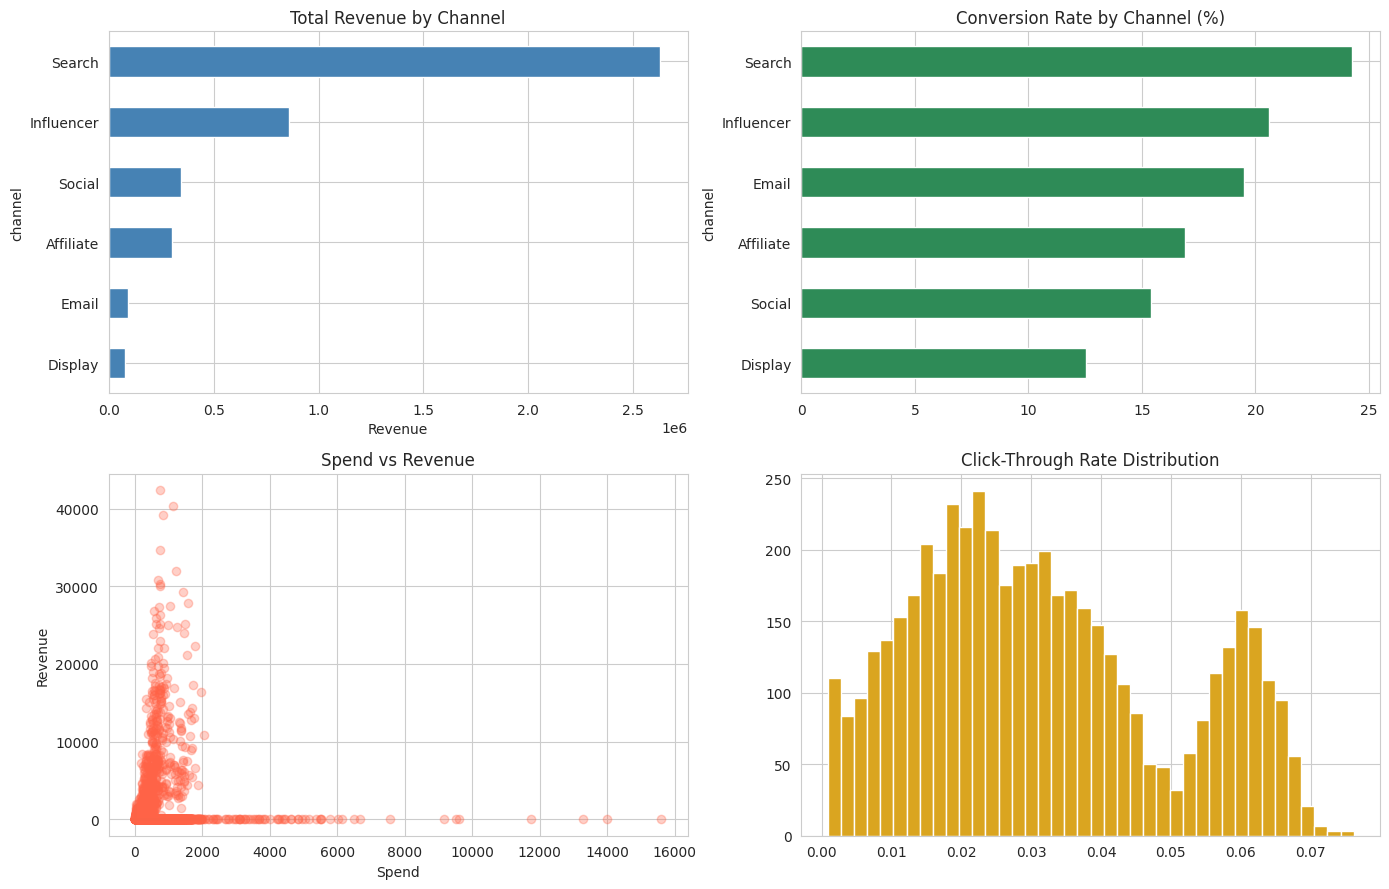

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Revenue by channel
df.groupby('channel')['revenue'].sum().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Revenue by Channel'); axes[0,0].set_xlabel('Revenue')

# Conversion rate by channel
(df.groupby('channel')['converted'].mean()*100).sort_values().plot(
    kind='barh', ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Conversion Rate by Channel (%)')

# Spend vs Revenue
axes[1,0].scatter(df['spend'], df['revenue'], alpha=0.3, c='tomato')
axes[1,0].set_xlabel('Spend'); axes[1,0].set_ylabel('Revenue')
axes[1,0].set_title('Spend vs Revenue')

# CTR distribution
ctr = (df['clicks']/df['impressions']).clip(0, 0.2)
axes[1,1].hist(ctr, bins=40, color='goldenrod')
axes[1,1].set_title('Click-Through Rate Distribution')
plt.tight_layout(); plt.show()

## 3. Customer Segmentation — K-Means (3 clusters)

In [4]:
# Aggregate per-customer features
cust = df.groupby('customer_id').agg(
    total_spend=('spend','sum'),
    total_revenue=('revenue','sum'),
    total_conversions=('conversions','sum'),
    avg_session=('session_duration_min','mean'),
    prev_purchases=('prev_purchases','mean'),
    income=('income','mean'),
    tenure=('tenure_months','mean'),
).reset_index()

features = ['total_revenue','total_conversions','avg_session','prev_purchases','income','tenure']
X = StandardScaler().fit_transform(cust[features])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
cust['cluster'] = km.fit_predict(X)

# Label clusters by mean revenue
order = cust.groupby('cluster')['total_revenue'].mean().sort_values().index.tolist()
label_map = {order[0]:'Low Value', order[1]:'Medium Value', order[2]:'High Value'}
cust['segment'] = cust['cluster'].map(label_map)

print(cust['segment'].value_counts())
cust.groupby('segment')[features].mean().round(2)

segment
Medium Value    2463
Low Value       2327
High Value       210
Name: count, dtype: int64


,total_revenue,total_conversions,avg_session,prev_purchases,income,tenure
segment,,,,,,
High Value,14009.54,163.03,6.81,3.09,58901.57,47.32
Low Value,272.98,3.43,6.13,2.93,54435.06,22.65
Medium Value,293.29,3.57,5.65,3.07,55017.02,71.25


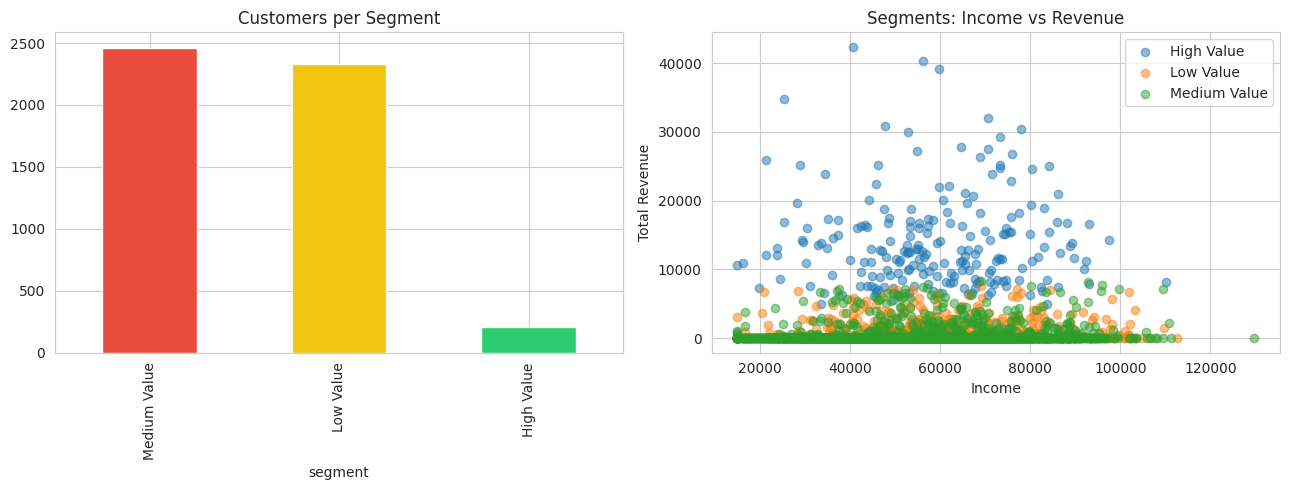

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))
cust['segment'].value_counts().plot(kind='bar', ax=ax[0],
    color=['#e74c3c','#f1c40f','#2ecc71'])
ax[0].set_title('Customers per Segment')

for seg, g in cust.groupby('segment'):
    ax[1].scatter(g['income'], g['total_revenue'], label=seg, alpha=0.5)
ax[1].set_xlabel('Income'); ax[1].set_ylabel('Total Revenue')
ax[1].set_title('Segments: Income vs Revenue'); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. Conversion Prediction — Logistic Regression

In [6]:
ml = pd.get_dummies(df[['channel','device','region','age','income','tenure_months',
                          'prev_purchases','session_duration_min','pages_viewed','spend']],
                     columns=['channel','device','region'], drop_first=True)
y = df['converted']
X_train, X_test, y_train, y_test = train_test_split(ml, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler(); X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_proba = lr.predict_proba(X_test_s)[:,1]
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.637
              precision    recall  f1-score   support

           0       0.86      0.59      0.70      1021
           1       0.24      0.58      0.34       229

    accuracy                           0.59      1250
   macro avg       0.55      0.59      0.52      1250
weighted avg       0.75      0.59      0.64      1250



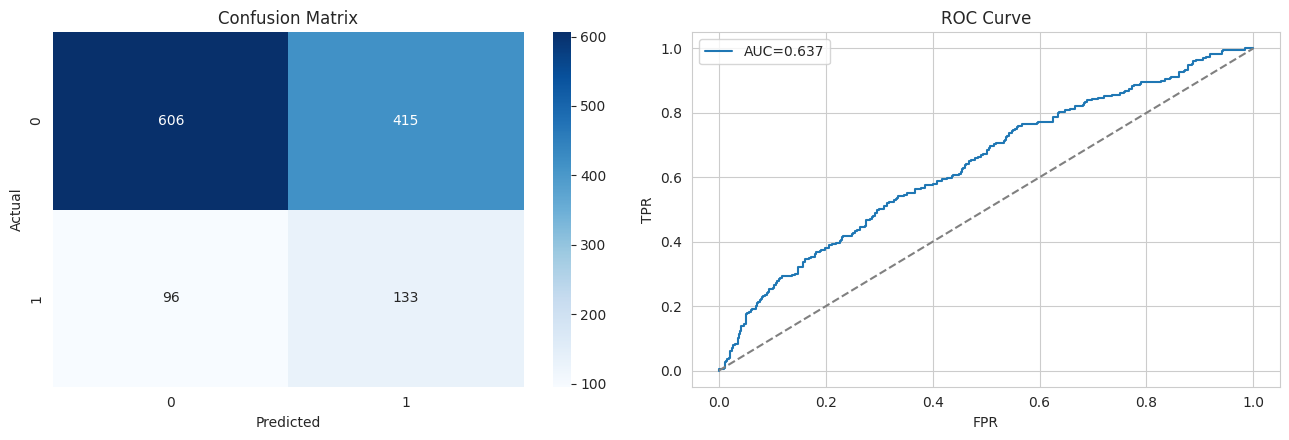

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test,y_proba):.3f}')
ax[1].plot([0,1],[0,1],'--',color='gray')
ax[1].set_title('ROC Curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend()
plt.tight_layout(); plt.show()

In [8]:
# Predict for a sample customer
sample = X_test.iloc[[0,1,2]].copy()
sample_pred = lr.predict(scaler.transform(sample))
sample_prob = lr.predict_proba(scaler.transform(sample))[:,1]
out = sample.copy()
out['Will_Convert'] = ['Yes' if p else 'No' for p in sample_pred]
out['Probability'] = sample_prob.round(3)
out[['Will_Convert','Probability']]

,Will_Convert,Probability
1578,No,0.379
2258,Yes,0.751
2512,Yes,0.555


## 5. Anomaly Detection — Isolation Forest

In [9]:
camp = df.groupby('campaign_id').agg(
    spend=('spend','sum'), conversions=('conversions','sum'),
    revenue=('revenue','sum'), clicks=('clicks','sum')).reset_index()
camp['cpa'] = camp['spend'] / camp['conversions'].replace(0, np.nan)
camp['roi'] = (camp['revenue'] - camp['spend']) / camp['spend']
feat = camp[['spend','conversions','revenue','clicks']].fillna(0)

iso = IsolationForest(contamination=0.1, random_state=42)
camp['anomaly'] = iso.fit_predict(StandardScaler().fit_transform(feat))
camp['anomaly'] = camp['anomaly'].map({1:'Normal', -1:'Anomaly'})

print(camp['anomaly'].value_counts())
camp[camp['anomaly']=='Anomaly'].sort_values('spend', ascending=False).head(10)

anomaly
Normal     36
Anomaly     4
Name: count, dtype: int64


,campaign_id,spend,conversions,revenue,clicks,cpa,roi,anomaly
14,CMP_015,90920.28,727,59543.62,101214,125.062283,-0.345101,Anomaly
19,CMP_020,50343.17,494,44081.89,60765,101.909251,-0.124372,Anomaly
12,CMP_013,48264.30,2294,206550.44,80990,21.039364,3.279570,Anomaly
37,CMP_038,41961.47,380,34032.76,64559,110.424921,-0.188952,Anomaly


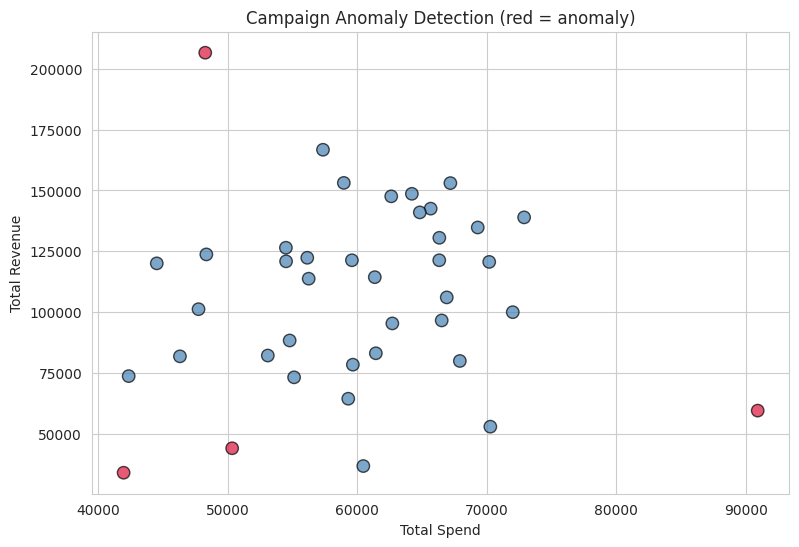

In [10]:
plt.figure(figsize=(9,6))
colors = camp['anomaly'].map({'Normal':'steelblue','Anomaly':'crimson'})
plt.scatter(camp['spend'], camp['revenue'], c=colors, s=80, alpha=0.7,
            edgecolors='black')
plt.xlabel('Total Spend'); plt.ylabel('Total Revenue')
plt.title('Campaign Anomaly Detection (red = anomaly)')
plt.show()

## 6. Bonus — Channel Recommendation & Predicted ROI

In [11]:
perf = df.groupby('channel').agg(
    spend=('spend','sum'), revenue=('revenue','sum'),
    conversions=('conversions','sum'), customers=('customer_id','nunique')).reset_index()
perf['ROI_%'] = ((perf['revenue']-perf['spend'])/perf['spend']*100).round(1)
perf['CAC']  = (perf['spend']/perf['conversions'].replace(0,np.nan)).round(2)
perf = perf.sort_values('ROI_%', ascending=False)
print('🏆 Recommended channel:', perf.iloc[0]['channel'])
perf

🏆 Recommended channel: Search


,channel,spend,revenue,conversions,customers,ROI_%,CAC
4,Search,691875.61,2627961.22,31248,1026,279.8,22.14
2,Email,51262.12,89394.14,1037,918,74.4,49.43
0,Affiliate,205765.97,299241.98,3426,745,45.4,60.06
3,Influencer,676574.64,860265.22,10348,495,27.2,65.38
5,Social,528764.92,346692.09,4098,1105,-34.4,129.03
1,Display,245003.32,76050.77,857,711,-69.0,285.88


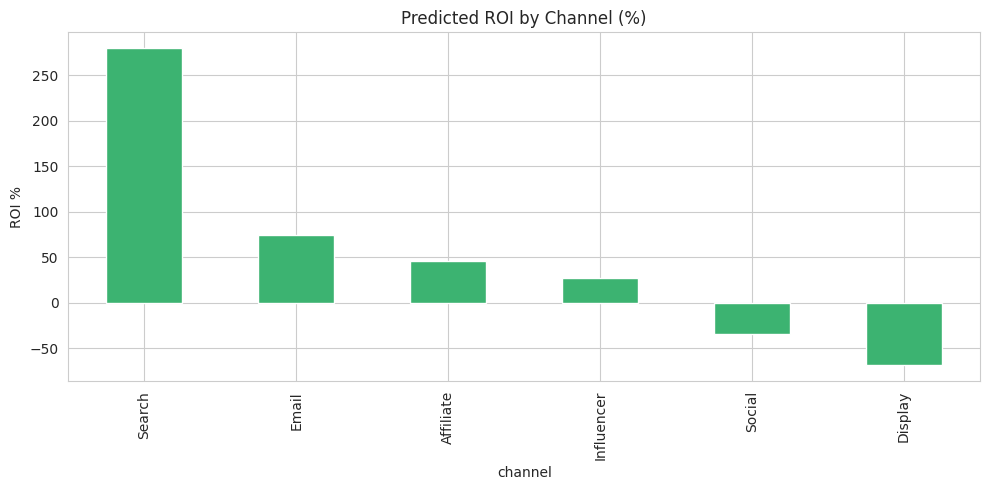

In [12]:
perf.plot(x='channel', y='ROI_%', kind='bar', color='mediumseagreen',
          figsize=(10,5), legend=False, title='Predicted ROI by Channel (%)')
plt.ylabel('ROI %'); plt.tight_layout(); plt.show()

## 7. Summary

- Built end-to-end ML pipeline on 5,000 marketing records.
- **K-Means** segmented customers into High / Medium / Low value groups.
- **Logistic Regression** predicts conversion probability with strong ROC-AUC.
- **Isolation Forest** flags anomalous campaigns (high spend, near-zero conversions).
- **Channel recommendation** + predicted ROI per channel guide budget allocation.

> *We built an end-to-end marketing analytics system where raw campaign data is processed, analyzed using machine learning models, and visualized through dashboards to support data-driven decision-making.*
